# **Etapa 02 - Modelagem com Redes Neurais**

**Objetivo:** Construir MLP utilizando PyTorch e comparar métricas do mesmo com modelos lineares e de árvores.

## **Imports e Setup Inicial de Valores**

In [83]:
#!pip install mlflow

In [84]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
import mlflow
import mlflow.pytorch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report,
    roc_auc_score,
    precision_recall_curve, 
    auc,
    confusion_matrix
)
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from IPython.display import display
from great_tables import GT, style, loc


RANDOM_STATE = 17
TEST_SIZE = 0.2


CUSTOMER_LTV = 1170.0
RETENTION_COST = 65.0
CONVERSION_RATE = 0.2


# Declaração do logger no escopo global
logger = logging.getLogger("tc_etapa_02")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## **Método para configuração do Logger**

In [85]:
def configurar_logging(nivel=logging.INFO):
    """
    Configura o logger global. Pode ser chamado múltiplas vezes
    para resetar as configurações durante a sessão.
    """
    # Limpa handlers existentes para evitar duplicação de logs
    if logger.hasHandlers():
        logger.handlers.clear()

    logger.setLevel(nivel)
    logger.propagate = False

    # Define o formato
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')

    # Handler para o console (saída no notebook)
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)


## **Carregamento de Dados**

In [86]:
def carregar_dados(path):
    """
    Carrega um arquivo Excel e retorna um DataFrame.
    """
    logger.info(f"Carregando dados do arquivo: {path}")
    df = pd.read_excel(path)
    return df

## **Tratamento dos dados**

In [87]:
def padronizar_nomes_features(df):
    """
    Padroniza os nomes das colunas para lowercase e substitui espaços por underscores.
    """
    logger.info("Padronizando nomes das colunas")
    df.columns = [c.lower().replace(" ", "_") for c in df.columns]
    return df

In [88]:
def corrigir_feature_total_charges(df):
  """
  Corrige a feature 'total_charges' para float64 e substitui NaN por 0.
  """
  logger.info("Corrigindo feature 'total_charges'")
  df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')
  df.fillna({'total_charges': 0}, inplace=True)
  return df

In [89]:
def remover_features_irrelevantes(df):
  """
  Remove features irrelevantes para o modelo.
  """
  logger.info("Removendo features irrelevantes")

  cols_to_drop = [
    "customerid",
    "count",
    "country",
    "state",
    "city",
    "lat_long",
    "latitude",
    "longitude",
    "churn_label",
    "churn_score",
    "cltv",
    "churn_reason"
  ]
  logger.debug(f"Features a serem removidas: {cols_to_drop}")
  df = df.drop(columns=cols_to_drop)
  return df

In [90]:
def criar_feature_average_monthly_spend(df):
  """
  Cria a feature 'average_monthly_spend' a partir de 'total_charges' e 'tenure_months'.
  """
  logger.info("Criando feature 'average_monthly_spend'")
  df['average_monthly_spend'] = df['total_charges'] / df['tenure_months']
  df['average_monthly_spend'] = df['average_monthly_spend'].replace([np.inf, -np.inf], 0).fillna(0)
  return df

In [91]:
def aplicar_feature_engineering(df):
  """
  Aplica todas as transformações de feature engineering.
  """
  logger.info("Aplicando feature engineering")
  df = criar_feature_average_monthly_spend(df)
  return df

In [92]:
def tratar_dados(df):
    """
    Aplica todos os tratamentos de dados.
    """
    logger.info("Tratando dados")
    df = padronizar_nomes_features(df)
    df = corrigir_feature_total_charges(df)
    df = remover_features_irrelevantes(df)
    return df

## **Separação de Dados de Treino e Teste**

In [93]:
def separar_dados_treino_teste(df):
  """
  Separa os dados em treino e teste.
  """
  logger.info("Separando dados em treino e teste")

  X = df.drop('churn_value', axis=1)
  y = df['churn_value']

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
  )

  return X_train, X_test, y_train, y_test

## **Construir Transformer para One-Hot Encoding**

In [94]:
def construir_transformer_hot_encoding(X_train):
  """
  Cria um transformer para one-hot encoding.
  """
  logger.info("Construindo transformer para one-hot encoding")

  colunas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns
  colunas_categoricas = X_train.select_dtypes(include=['object']).columns

  transformer = ColumnTransformer(
      transformers=[
          ('numerics', StandardScaler(), colunas_numericas),
          ('categoricals', OneHotEncoder(drop='first', handle_unknown='ignore'), colunas_categoricas)
      ]
  )

  return transformer

## **Construir Balanceador**

In [95]:
def construir_balanceador():
  """
  Cria um balanceador SMOTE.
  """
  logger.info("Construindo balanceador SMOTE")

  return SMOTE(random_state=RANDOM_STATE)

## **Construir Pipeline**

In [96]:
def construir_pipeline(nome_execucao, transformer, balanceador, modelo):
  """
  Cria um pipeline com o transformer, balanceador e modelo.
  """
  logger.info(f"Construindo pipeline para '{nome_execucao}'")

  pipeline = Pipeline(
    steps=[
        ('pre-processamento', transformer),
        ('balanceamento', balanceador),
        ('classificador', modelo)
    ]
  )

  return pipeline

## **Executar validação cruzada**

In [97]:
def executar_validacao_cruzada(nome_execucao, pipeline, X_train, y_train, folds=5):
  """
  Executa a validação cruzada com o pipeline e retorna os resultados.
  """
  logger.info(f"Executando validação cruzada para '{nome_execucao}'")

  metricas = ['accuracy', 'precision', 'recall', 'f1']
  resultados_cv = cross_validate(
      pipeline, X_train, y_train, cv=5, scoring=metricas
  )

  logger.debug(f"--- FASE DE VALIDAÇÃO CRUZADA (Média das {folds} Pastas) ---")
  logger.debug(f"Acurácia Média:   {resultados_cv['test_accuracy'].mean():.4f}")
  logger.debug(f"Precisão Média: {resultados_cv['test_precision'].mean():.4f}")
  logger.debug(f"Recall Médio:    {resultados_cv['test_recall'].mean():.4f}")
  logger.debug(f"F1-Score Médio:  {resultados_cv['test_f1'].mean():.4f}\n")

## **Treinamento e Teste do Modelo**

In [98]:
def treinar_e_testar_modelo(nome_execucao, pipeline, X_train, X_test, y_train, y_test):
  """
  Treina e testa o modelo.
  """
  logger.info(f"Treinando e testando modelo '{nome_execucao}'")

  pipeline.fit(X_train, y_train)

  previsoes = {}

  previsoes_train = pipeline.predict(X_train)
  previsoes_test = pipeline.predict(X_test)

  previsoes["previsoes_train"] = previsoes_train
  previsoes["previsoes_test"] = previsoes_test

  if (hasattr(pipeline, "predict_proba")):
    previsoes_train_proba = pipeline.predict_proba(X_train)[:, 1]
    previsoes_test_proba = pipeline.predict_proba(X_test)[:, 1]
  elif (hasattr(pipeline, "decision_function")):
    previsoes_train_proba = pipeline.decision_function(X_train)
    previsoes_test_proba = pipeline.decision_function(X_test)

  previsoes["previsoes_train_proba"] = previsoes_train_proba
  previsoes["previsoes_test_proba"] = previsoes_test_proba

  return previsoes

## **Análise de Custo Benefício**

In [99]:
def cost_benefit_analysis(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    customer_ltv: float,
    retention_cost: float,
    conversion_rate: float = 0.40,
    threshold: float = 0.5
) -> dict[str, float]:
    """Análise custo-benefício para classificação binária de churn.

    Args:
        y_true: Labels verdadeiros.
        y_proba: Probabilidades preditas.
        customer_ltv: Valor de Tempo de Vida do cliente (ou receita perdida se ele sair).
        retention_cost: Custo da ação de marketing/incentivo para reter o cliente.
        conversion_rate: Taxa de sucesso da ação (quantos % dos clientes propensos ao churn aceitam a oferta).
        threshold: Limiar de classificação para intervir.

    Returns:
        Dicionário com TP, FP, FN, TN e valor líquido.
    """
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # 1. Clientes salvos de fato (TP que converteram)
    saved_customers = tp * conversion_rate
    
    # 2. Clientes que mesmo com a oferta, deram churn (TP que NÃO converteram)
    lost_despite_offer = tp * (1 - conversion_rate)

    # --- CÁLCULO DO VALOR LÍQUIDO ---
    # Ganhos: Valor dos clientes salvos
    revenue_saved = saved_customers * customer_ltv
    
    # Custos: 
    # - Gastamos incentivo com TODO MUNDO que o modelo disparou o alarme (TP e FP)
    total_campaign_cost = (tp + fp) * retention_cost
    # - Perdemos o LTV dos que o modelo ignorou (FN) e dos que não aceitaram a oferta
    total_loss = (fn + lost_despite_offer) * customer_ltv

    # O valor líquido aqui representa o "balanço de perdas e ganhos" da operação
    # Comparado ao cenário base (não fazer nada e perder todos os churns reais: (tp + fn) * ltv)
    baseline_loss = (tp + fn) * customer_ltv
    current_loss = total_campaign_cost + total_loss
    net_value_saved = baseline_loss - current_loss

    logger.info(
        "Threshold=%.2f | Alvos: %d | Salvos Estimados: %.1f | Economia Líquida: R$ %.2f", 
        threshold, (tp + fp), saved_customers, net_value_saved
    )

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "saved_customers": float(saved_customers),
        "campaign_cost": float(total_campaign_cost),
        "net_value_saved": float(net_value_saved),
        "threshold": threshold
    }

## **Calcular Métricas**

In [100]:
def calcular_metricas(y_target, previsoes, previsoes_proba, label):
  """
  Calcula as métricas de avaliação.
  """
  logger.info("Calculando métricas")

  acuracia = accuracy_score(y_target, previsoes)
  precisao = precision_score(y_target, previsoes, pos_label=1)
  recall = recall_score(y_target, previsoes, pos_label=1)
  f1 = f1_score(y_target, previsoes, pos_label=1)
  rocauc = roc_auc_score(y_target, previsoes_proba)
  precisions, recalls, _ = precision_recall_curve(y_target, previsoes_proba)
  pr_auc = auc(recalls, precisions)

  logger.debug("--- MÉTRICAS DE EXECUÇÃO DO MODELO ---")
  logger.debug(f"Acurácia no {label}:  {acuracia:.4f}")
  logger.debug(f"Precisão no {label}: {precisao:.4f}")
  logger.debug(f"Recall no {label}:    {recall:.4f}")
  logger.debug(f"F1-Score no {label}:  {f1:.4f}")
  logger.debug(f"ROC-AUC no {label}:  {rocauc:.4f}")
  logger.debug(f"PR-AUC no {label}:  {pr_auc:.4f}\n")

  logger.debug("--- RELATÓRIO DE CLASSIFICAÇÃO DETALHADO ---")
  report = classification_report(y_target, previsoes)
  logger.debug(f"\n{report}")

  return acuracia, precisao, recall, f1, rocauc, pr_auc



## **Calcular Métricas de Treino e Teste**

In [101]:
def calcular_metricas_treino_teste(nome_execucao, y_train, y_test, previsoes):
  """
  Calcula as métricas de treino e teste.
  """
  logger.info(f"Calculando métricas de treino e teste para '{nome_execucao}")

  train_accuracy, train_precision, train_recall, train_f1, train_rocauc, train_pr_auc = calcular_metricas(y_train, previsoes["previsoes_train"], previsoes["previsoes_train_proba"], "TREINO")
  test_accuracy, test_precision, test_recall, test_f1, test_rocauc, test_pr_auc = calcular_metricas(y_test, previsoes["previsoes_test"], previsoes["previsoes_test_proba"], "TESTE")

  overfitting = train_accuracy - test_accuracy

  logger.debug("--- OVERFITTING ---")
  logger.debug(f"Overfitting: {overfitting:.4f}")

  metricas = {}
  metricas["train_accuracy"] = train_accuracy
  metricas["test_accuracy"] = test_accuracy
  metricas["train_precision"] = train_precision
  metricas["test_precision"] = test_precision
  metricas["train_recall"] = train_recall
  metricas["test_recall"] = test_recall
  metricas["train_f1"] = train_f1
  metricas["test_f1"] = test_f1
  metricas["train_rocauc"] = train_rocauc
  metricas["test_rocauc"] = test_rocauc
  metricas["train_pr_auc"] = train_pr_auc
  metricas["test_pr_auc"] = test_pr_auc
  metricas["overfitting"] = overfitting

  return metricas

## **Registrar Execução no MLFlow**

In [102]:
def registrar_execucao_mlflow(
    nome_execucao,
    metricas,
    model,
    mlp = False
):
  """
  Registra a execução no MLFlow.
  """
  logger.info("Registrando execução no MLFlow")
  with mlflow.start_run(run_name=nome_execucao):
    mlflow.log_metric("train_accuracy", metricas["train_accuracy"])
    mlflow.log_metric("test_accuracy", metricas["test_accuracy"])
    mlflow.log_metric("train_precision", metricas["train_precision"])
    mlflow.log_metric("test_precision", metricas["test_precision"])
    mlflow.log_metric("train_recall", metricas["train_recall"])
    mlflow.log_metric("test_recall", metricas["test_recall"])
    mlflow.log_metric("train_f1_score", metricas["train_f1"])
    mlflow.log_metric("test_f1_score", metricas["test_f1"])
    mlflow.log_metric("train_roc_auc", metricas["train_rocauc"])
    mlflow.log_metric("test_roc_auc", metricas["test_rocauc"])
    mlflow.log_metric("train_pr_auc", metricas["train_pr_auc"])
    mlflow.log_metric("test_pr_auc", metricas["test_pr_auc"])
    mlflow.log_metric("overfitting", metricas["overfitting"])
    if mlp:
      mlflow.pytorch.log_model(model, "model")
    else:
      mlflow.sklearn.log_model(model, "model")

## **Registrar Métricas do Modelo**

In [103]:
def registrar_metricas_modelo(modelo, metricas, metricas_todos_modelos):
  """
  Registra as métricas do modelo.
  """
  logger.info("Registrando métricas do modelo")
  metricas_todos_modelos.append({
      "Modelo": modelo,
      "Accuracy": metricas["test_accuracy"],
      "Precision": metricas["test_precision"],
      "Recall": metricas["test_recall"],
      "F1-Score": metricas["test_f1"],
      "ROC-AUC": metricas["test_rocauc"],
      "PR-AUC": metricas["test_pr_auc"],
      "Overfitting": metricas["overfitting"]
  })

## **Obter Melhor Custo/Benefício do Modelo**

In [104]:
def obter_melhor_custo_beneficio_modelo(nome_execucao, y_test, previsoes_test_proba):
    """
    Obtém o melhor custo/benefício para thresholds de 0.1 a 0.9.
    """
    logger.info(f"--- Análise Custo/Benefício ({nome_execucao}) ---")

    melhor_custo_beneficio = None
    for threshold in np.arange(0.1, 0.9, 0.05):
        custo_beneficio = cost_benefit_analysis(
            y_true=y_test, 
            y_proba=previsoes_test_proba, 
            threshold=threshold,
            customer_ltv=CUSTOMER_LTV,
            retention_cost=RETENTION_COST,
            conversion_rate=CONVERSION_RATE
        )

        if melhor_custo_beneficio is None or custo_beneficio["net_value_saved"] > melhor_custo_beneficio["net_value_saved"]:
            melhor_custo_beneficio = custo_beneficio
    
    return melhor_custo_beneficio


## **Avaliar Modelo**

In [105]:
def avaliar_modelo(nome_execucao, transformer, balanceador, modelo, X_train, y_train, X_test, y_test):
  """
  Avalia o modelo.
  """
  logger.info("Avaliando modelo")

  pipeline = construir_pipeline(nome_execucao, transformer, balanceador, modelo)

  #executar_validacao_cruzada(nome_execucao, pipeline, X_train, y_train)

  previsoes = treinar_e_testar_modelo(nome_execucao, pipeline, X_train, X_test, y_train, y_test)

  melhor_custo_beneficio = obter_melhor_custo_beneficio_modelo(nome_execucao, y_test, previsoes["previsoes_test_proba"])

  metricas = calcular_metricas_treino_teste(nome_execucao, y_train, y_test, previsoes)

  registrar_execucao_mlflow(nome_execucao, metricas, modelo)

  return_data = {
    "modelo": nome_execucao,
    "metricas": metricas,
    "custo_beneficio": melhor_custo_beneficio
  }

  return return_data

## **Configurar MLFlow**

In [106]:
def configurar_mlflow():
  """
  Configura o MLFlow.
  """
  logger.info("Configurando MLFlow")

  # Identificar arquivo com fallback de ambientes (Local vs Colab)
  caminho_local = "../data/mlflow_tracking/"
  caminho_colab = "/content/"

  if os.path.exists(caminho_local):
    path = caminho_local
  elif os.path.exists(caminho_colab):
    path = caminho_colab
  else:
    logger.error("Erro: pasta de armazenamento do MLFlow não foi encontrada localmente nem no caminho padrão do Colab.")
    sys.exit(1)

  os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
  mlflow.set_tracking_uri(path)
  mlflow.set_experiment("TechChallenge - Etapa 02")


## **Executar Modelo LogisticRegression**

In [107]:
def executar_logistic_regression(X_train, X_test, y_train, y_test, transformer, balanceador):
  """
  Executa o modelo LogisticRegression.
  """
  logger.info("Executando modelo LogisticRegression")

    # Obter modelo
  modelo = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight="balanced")

  # Avaliar modelo
  metricas = avaliar_modelo("Logistic Regression", transformer, balanceador, modelo, X_train, y_train, X_test, y_test)

  return metricas

## **Executar Modelo DecisionTreeClassifier**

In [108]:
def executar_decision_tree_classifier(X_train, X_test, y_train, y_test, transformer, balanceador):
  """
  Executa o modelo DecisionTreeClassifier.
  """
  logger.info("Executando modelo DecisionTreeClassifier")

  # Obter modelo
  modelo = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=5)

  # Avaliar modelo
  dados_avaliacao = avaliar_modelo("Decision Tree Classifier", transformer, balanceador, modelo, X_train, y_train, X_test, y_test)

  return dados_avaliacao

## **Executar Modelo RandomForestClassifier**

In [109]:
def executar_random_forest_classifier(X_train, X_test, y_train, y_test, transformer, balanceador):
  """
  Executa o modelo RandomForestClassifier.
  """
  logger.info("Executando modelo RandomForestClassifier")

  # Obter modelo
  modelo = RandomForestClassifier(random_state=RANDOM_STATE, max_depth=5)

  # Avaliar modelo
  dados_avaliacao = avaliar_modelo("Random Forest Classifier", transformer, balanceador, modelo, X_train, y_train, X_test, y_test)

  return dados_avaliacao

## **Executar Modelo GradientBoostingClassifier**

In [110]:
def executar_gradient_boosting_classifier(X_train, X_test, y_train, y_test, transformer, balanceador):
  """
  Executa o modelo GradientBoostingClassifier.
  """
  logger.info("Executando modelo GradientBoostingClassifier")

  # Obter modelo
  modelo = GradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=5)

  # Avaliar modelo
  dados_avaliacao = avaliar_modelo("Gradient Boosting Classifier", transformer, balanceador, modelo, X_train, y_train, X_test, y_test)

  return dados_avaliacao

## **Construir Modelo MLP (PyTorch)**

In [111]:
def criar_modelo(input_dim=30):
    """
    Cria e retorna o modelo PyTorch Sequential.
    """
    logger.info(f"Criando modelo MLP Sequencial com input_dim={input_dim}")

    model = nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.BatchNorm1d(64),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.3),
        nn.Linear(64, 32),
        nn.BatchNorm1d(32),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.2),
        nn.Linear(32, 1)
    )

    return model

## **Preparar Dataloaders para uso do MLP**

In [112]:
def preparar_dataloaders(X_train, y_train, X_val, y_val, batch_size=64):
    """
    Converte os arrays NumPy em Tensores PyTorch e instancia os DataLoaders.
    """
    logger.info("Preparando DataLoaders do PyTorch")

    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train.values if hasattr(y_train, 'values') else y_train).view(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val.values if hasattr(y_val, 'values') else y_val).view(-1, 1)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader

## **Treinar Modelo MLP**

In [113]:
def treinar_modelo_mlp(model, train_loader, val_loader, epochs=100, lr=0.001, patience=5, min_delta=0.001):
    """
    Loop de treinamento do PyTorch com lógica de Early Stopping integrada.
    """
    logger.info("Iniciando loop de treinamento...")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_loss = None
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # --- Fase de Treinamento ---
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- Fase de Validação ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        logger.info(f"Epoch {epoch + 1:03d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Lógica de Early Stopping
        if best_loss is None:
            best_loss = avg_val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif avg_val_loss > best_loss - min_delta:
            patience_counter += 1
            if patience_counter >= patience:
                logger.info(f"Early stopping ativado na época {epoch + 1}! O erro de validação parou de cair.")
                break
        else:
            best_loss = avg_val_loss
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Restaura os melhores pesos alcançados durante o treinamento
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        logger.info("Melhor estado do modelo restaurado.")

    return model

## **Obter as Previsões do Modelo MLP**

In [114]:
def obter_previsoes_mlp(model, X_data):
    """
    Executa a inferência e retorna classes preditas (0 ou 1) e probabilidades brutas.
    """
    logger.info("Obtendo previsões do modelo MLP")

    model.eval()

    X_tensor = torch.FloatTensor(X_data)

    with torch.no_grad():
        logits = model(X_tensor)
        probs = torch.sigmoid(logits).numpy()
        preds = (probs >= 0.5).astype(int)

    return preds.flatten(), probs.flatten()

## **Executar Modelo MLP**

In [115]:
def executar_modelo_mlp(X_train, X_test, y_train, y_test, transformer, balanceador):
    """
    Prepara os dados, executa treinamento e validação, avalia e salva resultados da MLP.
    """
    logger.info("Executando Modelo MLP")

    logger.debug("Aplicando transformação dos dados")
    X_train_trans = transformer.fit_transform(X_train)
    X_test_trans = transformer.transform(X_test)

    logger.debug("Convertendo para Dense Array se for matriz esparsa")
    if hasattr(X_train_trans, "toarray"):
        X_train_trans = X_train_trans.toarray()
    if hasattr(X_test_trans, "toarray"):
        X_test_trans = X_test_trans.toarray()

    # Dividir o conjunto de treino original transformado em sub-treino e validação
    # para monitoramento do early stopping, isolando totalmente o conjunto de teste.
    X_sub_train, X_val, y_sub_train, y_val = train_test_split(
        X_train_trans, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
    )

    logger.debug("Balanceando os dados")
    X_sub_train_res, y_sub_train_res = balanceador.fit_resample(X_sub_train, y_sub_train)

    train_loader, val_loader = preparar_dataloaders(X_sub_train_res, y_sub_train_res, X_val, y_val, batch_size=64)

    model = criar_modelo(input_dim=X_sub_train_res.shape[1])

    treinar_modelo_mlp(model, train_loader, val_loader, epochs=100, lr=0.001, patience=5)

    preds_train, preds_proba_train = obter_previsoes_mlp(model, X_train_trans)
    preds_test, preds_proba_test = obter_previsoes_mlp(model, X_test_trans)

    previsoes = {
        "previsoes_train": preds_train,
        "previsoes_train_proba": preds_proba_train,
        "previsoes_test": preds_test,
        "previsoes_test_proba": preds_proba_test
    }

    nome_execucao = "MLP (PyTorch)"

    metricas = calcular_metricas_treino_teste(nome_execucao, y_train, y_test, previsoes)

    registrar_execucao_mlflow(nome_execucao, metricas, model, True)

    melhor_custo_beneficio = obter_melhor_custo_beneficio_modelo(nome_execucao, y_test, previsoes["previsoes_test_proba"])

    return_data = {
        "modelo": nome_execucao,
        "metricas": metricas,
        "custo_beneficio": melhor_custo_beneficio
    }

    return return_data

## **Exibir gráfico comparativo métricas/modelo**

In [116]:
def exibir_grafico_comparativo_metricas_modelo(df_metricas):
  """
  Exibe o gráfico comparativo métricas/modelo.
  """
  logger.info("Exibindo gráfico comparativo métricas/modelo")

  metricas = [
      "Accuracy",
      "Precision",
      "Recall",
      "F1-Score",
      "ROC-AUC",
      "PR-AUC",
      "Overfitting"
  ]

  plt.figure(figsize=(18, 15))

  for i, col in enumerate(metricas):
      plt.subplot(3, 3, i+1)
      sns.barplot(
          data=df_metricas,
          x="Modelo",
          hue="Modelo",
          y=col,
          palette='Set2',
          legend=False
      )
      plt.title(f'Métrica: {col}', fontweight='bold', fontsize=12)
      plt.xlabel('Modelos', fontsize=10)
      plt.ylabel('Valor', fontsize=10)
      plt.xticks(rotation=75) # Rotaciona o nome dos modelos se forem grandes
      plt.grid(axis='y', linestyle='--', alpha=0.7) # Linhas de grade para facilitar leitura

  plt.suptitle('Comparativo de Métricas entre os Modelos', fontsize=16, fontweight='bold', y=0.98)
  plt.tight_layout()
  plt.savefig('../reports/figures/etapa02_grafico_comparativo_metricas_modelos.png', dpi=300, bbox_inches='tight')
  plt.show()

## **Exibir Tabela Comparativa de Métricas entre Modelos**

In [117]:
def display_metrics_table(df):
    """
    Exibe uma tabela comparativa de métricas entre os modelos
    """
    # 1. Initialize the Great Table
    gt_table = (
        GT(df)
        .tab_header(
            title="Comparação de Performance entre Modelos",
            subtitle="Ordenado por PR-AUC de forma descendente"
        )
        .fmt_number(
            columns=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "PR-AUC", "Overfitting"],
            decimals=3
        )
    )
    
    norm = colors.Normalize(vmin=df['PR-AUC'].min(), vmax=df['PR-AUC'].max())
    cmap = cm._colormaps.get_cmap('Greens')
    
    gradient_colors = [colors.to_hex(cmap(norm(val))) for val in df['PR-AUC']]
    
    for i, color in enumerate(gradient_colors):
        gt_table = gt_table.tab_style(
            style=style.fill(color=color),
            locations=loc.body(columns=["PR-AUC"], rows=i)
        )
        
        if norm(df['PR-AUC'].iloc[i]) > 0.7:
            gt_table = gt_table.tab_style(
                style=style.text(color="white", weight="bold"),
                locations=loc.body(columns=["PR-AUC"], rows=i)
            )

    gt_table.gtsave("../reports/figures/etapa02_tabela_comparativa_metricas_modelos.png")
    display(gt_table)

## **Exibir Tabela Comparativa Custo Benefício entre Modelos**

In [118]:
def display_cost_benefit_table(df):
    """
    Exibe uma tabela comparativa de custo benefício entre os modelos
    """
    VALOR_SALVO = "Valor Salvo"

    # 1. Initialize the Great Table
    gt_table = (
        GT(df)
        .tab_header(
            title="Comparação de Custo/Benefício entre Modelos",
            subtitle="Ordenado por Valor Líquido de Economia de forma ascendente"
        )
        .fmt_number(
            columns=[VALOR_SALVO, "Threshold"],
            decimals=2
        )
    )
    
    norm = colors.Normalize(vmin=df[VALOR_SALVO].min(), vmax=df[VALOR_SALVO].max())
    cmap = cm._colormaps.get_cmap('Greens')
    
    gradient_colors = [colors.to_hex(cmap(norm(val))) for val in df[VALOR_SALVO]]
    
    for i, color in enumerate(gradient_colors):
        gt_table = gt_table.tab_style(
            style=style.fill(color=color),
            locations=loc.body(columns=[VALOR_SALVO], rows=i)
        )
        
        if norm(df[VALOR_SALVO].iloc[i]) > 0.7:
            gt_table = gt_table.tab_style(
                style=style.text(color="white", weight="bold"),
                locations=loc.body(columns=[VALOR_SALVO], rows=i)
            )

    gt_table.gtsave("../reports/figures/etapa02_tabela_comparativa_custo_beneficio_modelos.png")
    display(gt_table)

## **Exibir Comparativos entre Modelos**

In [119]:
def exibir_comparativos_modelos(metricas_todos_modelos, custo_beneficio_modelos):
  """
  Exibe os comparativos entre os modelos.
  """
  logger.info("Exibindo comparativos entre os modelos")
  
  df_metricas = pd.DataFrame(metricas_todos_modelos)
  df_metricas = df_metricas.sort_values(by="PR-AUC", ascending=False)

  df_custo_beneficio = pd.DataFrame(custo_beneficio_modelos)
  df_custo_beneficio = df_custo_beneficio.sort_values(by="Valor Salvo", ascending=False)

  display_metrics_table(df_metricas)

  display_cost_benefit_table(df_custo_beneficio)

  exibir_grafico_comparativo_metricas_modelo(df_metricas)

## **Identificar Path do Arquivo de Dados**

In [120]:
def identificar_path_arquivo_dados():
  """
  Identifica o path do arquivo de dados.
  """
  logger.info("Identificando path do arquivo de dados")

  # Identificar arquivo com fallback de ambientes (Local vs Colab)
  caminho_local = "../data/raw/Telco_customer_churn.xlsx"
  caminho_colab = "/content/Telco_customer_churn.xlsx"

  if os.path.exists(caminho_local):
      path = caminho_local
  elif os.path.exists(caminho_colab):
      path = caminho_colab
  else:
      logger.error("Erro: Base de dados Telco_customer_churn.xlsx não foi encontrada localmente nem no caminho padrão do Colab.")
      sys.exit(1)

  return path

## **Registrar Custo Benefício do Modelo**

In [121]:
def registrar_custo_beneficio_modelo(modelo, custo_beneficio, custo_beneficio_modelos):
  """
  Registra o custo benefício do modelo.
  """
  logger.info("Registrando custo benefício do modelo")
  custo_beneficio_modelos.append({
      "Modelo": modelo,
      "TP": custo_beneficio["tp"],
      "FP": custo_beneficio["fp"],
      "FN": custo_beneficio["fn"],
      "TN": custo_beneficio["tn"],
      "Valor Salvo": custo_beneficio["net_value_saved"],
      "Threshold": custo_beneficio["threshold"]
  })

## **Execução Geral do 'Programa'**

In [122]:
def main():
  logger.info("Iniciando o programa")

  # Configurar o Logger
  configurar_logging(logging.DEBUG)

  # Identificar path do arquivo de dados
  path = identificar_path_arquivo_dados()

  # Carregar dados
  df = carregar_dados(path)

  # Tratamento dos dados
  df = tratar_dados(df)

  # Separar dados de treino e teste
  X_train, X_test, y_train, y_test = separar_dados_treino_teste(df)

  # Obter transformer
  transformer = construir_transformer_hot_encoding(X_train)

  # Obter balanceador
  balanceador = construir_balanceador()

  # Configurar o MLFlow
  configurar_mlflow()

  # Buffer para coletar as métricas de todos os modelos
  metricas_todos_modelos = []

  # Buffer para coletar cálculos de custo benefício dos modelos
  custo_beneficio_modelos = []

  # Executar o modelo LogisticRegression
  dados_avaliacao = executar_logistic_regression(X_train, X_test, y_train, y_test, transformer, balanceador)
  registrar_metricas_modelo(dados_avaliacao["modelo"], dados_avaliacao["metricas"], metricas_todos_modelos)
  registrar_custo_beneficio_modelo(dados_avaliacao["modelo"], dados_avaliacao["custo_beneficio"], custo_beneficio_modelos)

  # Executar o modelo DecisionTreeClassifier
  dados_avaliacao = executar_decision_tree_classifier(X_train, X_test, y_train, y_test, transformer, balanceador)
  registrar_metricas_modelo(dados_avaliacao["modelo"], dados_avaliacao["metricas"], metricas_todos_modelos)
  registrar_custo_beneficio_modelo(dados_avaliacao["modelo"], dados_avaliacao["custo_beneficio"], custo_beneficio_modelos)

  # Executar o modelo RandomForestClassifier
  dados_avaliacao = executar_random_forest_classifier(X_train, X_test, y_train, y_test, transformer, balanceador)
  registrar_metricas_modelo(dados_avaliacao["modelo"], dados_avaliacao["metricas"], metricas_todos_modelos)
  registrar_custo_beneficio_modelo(dados_avaliacao["modelo"], dados_avaliacao["custo_beneficio"], custo_beneficio_modelos)

  # Executar o modelo GradientBoostingClassifier
  dados_avaliacao = executar_gradient_boosting_classifier(X_train, X_test, y_train, y_test, transformer, balanceador)
  registrar_metricas_modelo(dados_avaliacao["modelo"], dados_avaliacao["metricas"], metricas_todos_modelos)
  registrar_custo_beneficio_modelo(dados_avaliacao["modelo"], dados_avaliacao["custo_beneficio"], custo_beneficio_modelos)

  # Executar o modelo MLP (PyTorch)
  dados_avaliacao = executar_modelo_mlp(X_train, X_test, y_train, y_test, transformer, balanceador)
  registrar_metricas_modelo(dados_avaliacao["modelo"], dados_avaliacao["metricas"], metricas_todos_modelos)
  registrar_custo_beneficio_modelo(dados_avaliacao["modelo"], dados_avaliacao["custo_beneficio"], custo_beneficio_modelos)

  # Exibir comparativo
  exibir_comparativos_modelos(metricas_todos_modelos, custo_beneficio_modelos)

  logger.info("Programa finalizado")

2026-06-11 22:40:07,879 - tc_etapa_02 - INFO - Iniciando o programa
2026-06-11 22:40:07,880 - tc_etapa_02 - INFO - Identificando path do arquivo de dados
2026-06-11 22:40:07,882 - tc_etapa_02 - INFO - Carregando dados do arquivo: ../data/raw/Telco_customer_churn.xlsx
2026-06-11 22:40:11,684 - tc_etapa_02 - INFO - Tratando dados
2026-06-11 22:40:11,686 - tc_etapa_02 - INFO - Padronizando nomes das colunas
2026-06-11 22:40:11,687 - tc_etapa_02 - INFO - Corrigindo feature 'total_charges'
2026-06-11 22:40:11,690 - tc_etapa_02 - INFO - Removendo features irrelevantes
2026-06-11 22:40:11,691 - tc_etapa_02 - DEBUG - Features a serem removidas: ['customerid', 'count', 'country', 'state', 'city', 'lat_long', 'latitude', 'longitude', 'churn_label', 'churn_score', 'cltv', 'churn_reason']
2026-06-11 22:40:11,696 - tc_etapa_02 - INFO - Separando dados em treino e teste
2026-06-11 22:40:11,718 - tc_etapa_02 - INFO - Construindo transformer para one-hot encoding
2026-06-11 22:40:11,721 - tc_etapa_02 

GT(_tbl_data=                         Modelo  Accuracy  Precision    Recall  F1-Score  \
1      Decision Tree Classifier  0.784954   0.572008  0.754011  0.650519   
3  Gradient Boosting Classifier  0.813343   0.637717  0.687166  0.661519   
4                 MLP (PyTorch)  0.778566   0.559846  0.775401  0.650224   
0           Logistic Regression  0.772889   0.550000  0.794118  0.649891   
2      Random Forest Classifier  0.772889   0.550562  0.786096  0.647577   

    ROC-AUC    PR-AUC  Overfitting  
1  0.844215  0.690110    -0.011791  
3  0.873008  0.688296     0.048390  
4  0.866421  0.680964    -0.002209  
0  0.863538  0.677792    -0.010198  
2  0.863605  0.671746     0.007552  , _body=<great_tables._gt_data.Body object at 0x000001A5930A9130>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Precision', type=<ColInfoTypeEnum.default: 1>, column_label='Precision', column_align='right', column_width=None), ColInfo(var='Recall', type=<ColInfoTypeEnum.default: 1>, column_label='Recall', column_align='right', column_width=None), ColInfo(var='F1-Score', type=<ColInfoTypeEnum.default: 1>, column_label='F1-Score', column_align='right', column_width=None), ColInfo(var='ROC-AUC', type=<ColInfoTypeEnum.default: 1>, column_label='ROC-AUC', column_align='right', column_width=None), ColInfo(var='PR-AUC', type=<ColInfoTypeEnum.default: 1>, column_label='PR-AUC', column_align='right', column_width=None), ColInfo(var='Overfitting', type=<ColInfoTypeEnum.default: 1>, column_label='Overfitting', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001A59312CF50>, _spanners=Spanners([]), _heading=Heading(title='Comparação de Performance entre Modelos', subtitle='Ordenado por PR-AUC de forma descendente', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001A59312CCB0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001A59312FA70>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=0, mask=None), grpname=None, colname='PR-AUC', rownum=0, colnum=None, styles=[CellStyleFill(color='#00441b')]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=0, mask=None), grpname=None, colname='PR-AUC', rownum=0, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=1, mask=None), grpname=None, colname='PR-AUC', rownum=1, colnum=None, styles=[CellStyleFill(color='#006428')]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=1, mask=None), grpname=None, colname='PR-AUC', rownum=1, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=2, mask=None), grpname=None, colname='PR-AUC', rownum=2, colnum=None, styles=[CellStyleFill(color='#73c476')]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=3, mask=None), grpname=None, colname='PR-AUC', rownum=3, colnum=None, styles=[CellStyleFill(color='#afdfa8')]), StyleInfo(locname=LocBody(columns=['PR-AUC'], rows=4, mask=None), grpname=None, colname='PR-AUC', rownum=4, colnum=None, styles=[CellStyleFill(color='#f7fcf5')])], _locale=<great_tables._gt_data.Locale object at 0x000001A5BA41AB40>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001A5BA0FF830>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', 

GT(_tbl_data=                         Modelo   TP   FP  FN   TN  Valor Salvo  Threshold
3  Gradient Boosting Classifier  303  231  71  804      36192.0       0.35
2      Random Forest Classifier  318  293  56  742      34697.0       0.45
4                 MLP (PyTorch)  306  263  68  772      34619.0       0.45
0           Logistic Regression  312  279  62  756      34593.0       0.45
1      Decision Tree Classifier  282  211  92  824      33943.0       0.50, _body=<great_tables._gt_data.Body object at 0x000001A593108C50>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='TP', type=<ColInfoTypeEnum.default: 1>, column_label='TP', column_align='right', column_width=None), ColInfo(var='FP', type=<ColInfoTypeEnum.default: 1>, column_label='FP', column_align='right', column_width=None), ColInfo(var='FN', type=<ColInfoTypeEnum.default: 1>, column_label='FN', column_align='right', column_width=None), ColInfo(var='TN', type=<ColInfoTypeEnum.default: 1>, column_label='TN', column_align='right', column_width=None), ColInfo(var='Valor Salvo', type=<ColInfoTypeEnum.default: 1>, column_label='Valor Salvo', column_align='right', column_width=None), ColInfo(var='Threshold', type=<ColInfoTypeEnum.default: 1>, column_label='Threshold', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000001A5AAC82120>, _spanners=Spanners([]), _heading=Heading(title='Comparação de Custo/Benefício entre Modelos', subtitle='Ordenado por Valor Líquido de Economia de forma ascendente', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000001A5BA41AA50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000001A5BA41B290>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=0, mask=None), grpname=None, colname='Valor Salvo', rownum=0, colnum=None, styles=[CellStyleFill(color='#00441b')]), StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=0, mask=None), grpname=None, colname='Valor Salvo', rownum=0, colnum=None, styles=[CellStyleText(color='white', font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=1, mask=None), grpname=None, colname='Valor Salvo', rownum=1, colnum=None, styles=[CellStyleFill(color='#aedea7')]), StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=2, mask=None), grpname=None, colname='Valor Salvo', rownum=2, colnum=None, styles=[CellStyleFill(color='#b8e3b2')]), StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=3, mask=None), grpname=None, colname='Valor Salvo', rownum=3, colnum=None, styles=[CellStyleFill(color='#bce4b5')]), StyleInfo(locname=LocBody(columns=['Valor Salvo'], rows=4, mask=None), grpname=None, colname='Valor Salvo', rownum=4, colnum=None, styles=[CellStyleFill(color='#f7fcf5')])], _locale=<great_tables._gt_data.Locale object at 0x000001A5BA419E80>, _formats=[<great_tables._gt_data.FormatInfo object at 0x000001A5BA418DD0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', val

2026-06-11 22:41:02,404 - tc_etapa_02 - INFO - Exibindo gráfico comparativo métricas/modelo


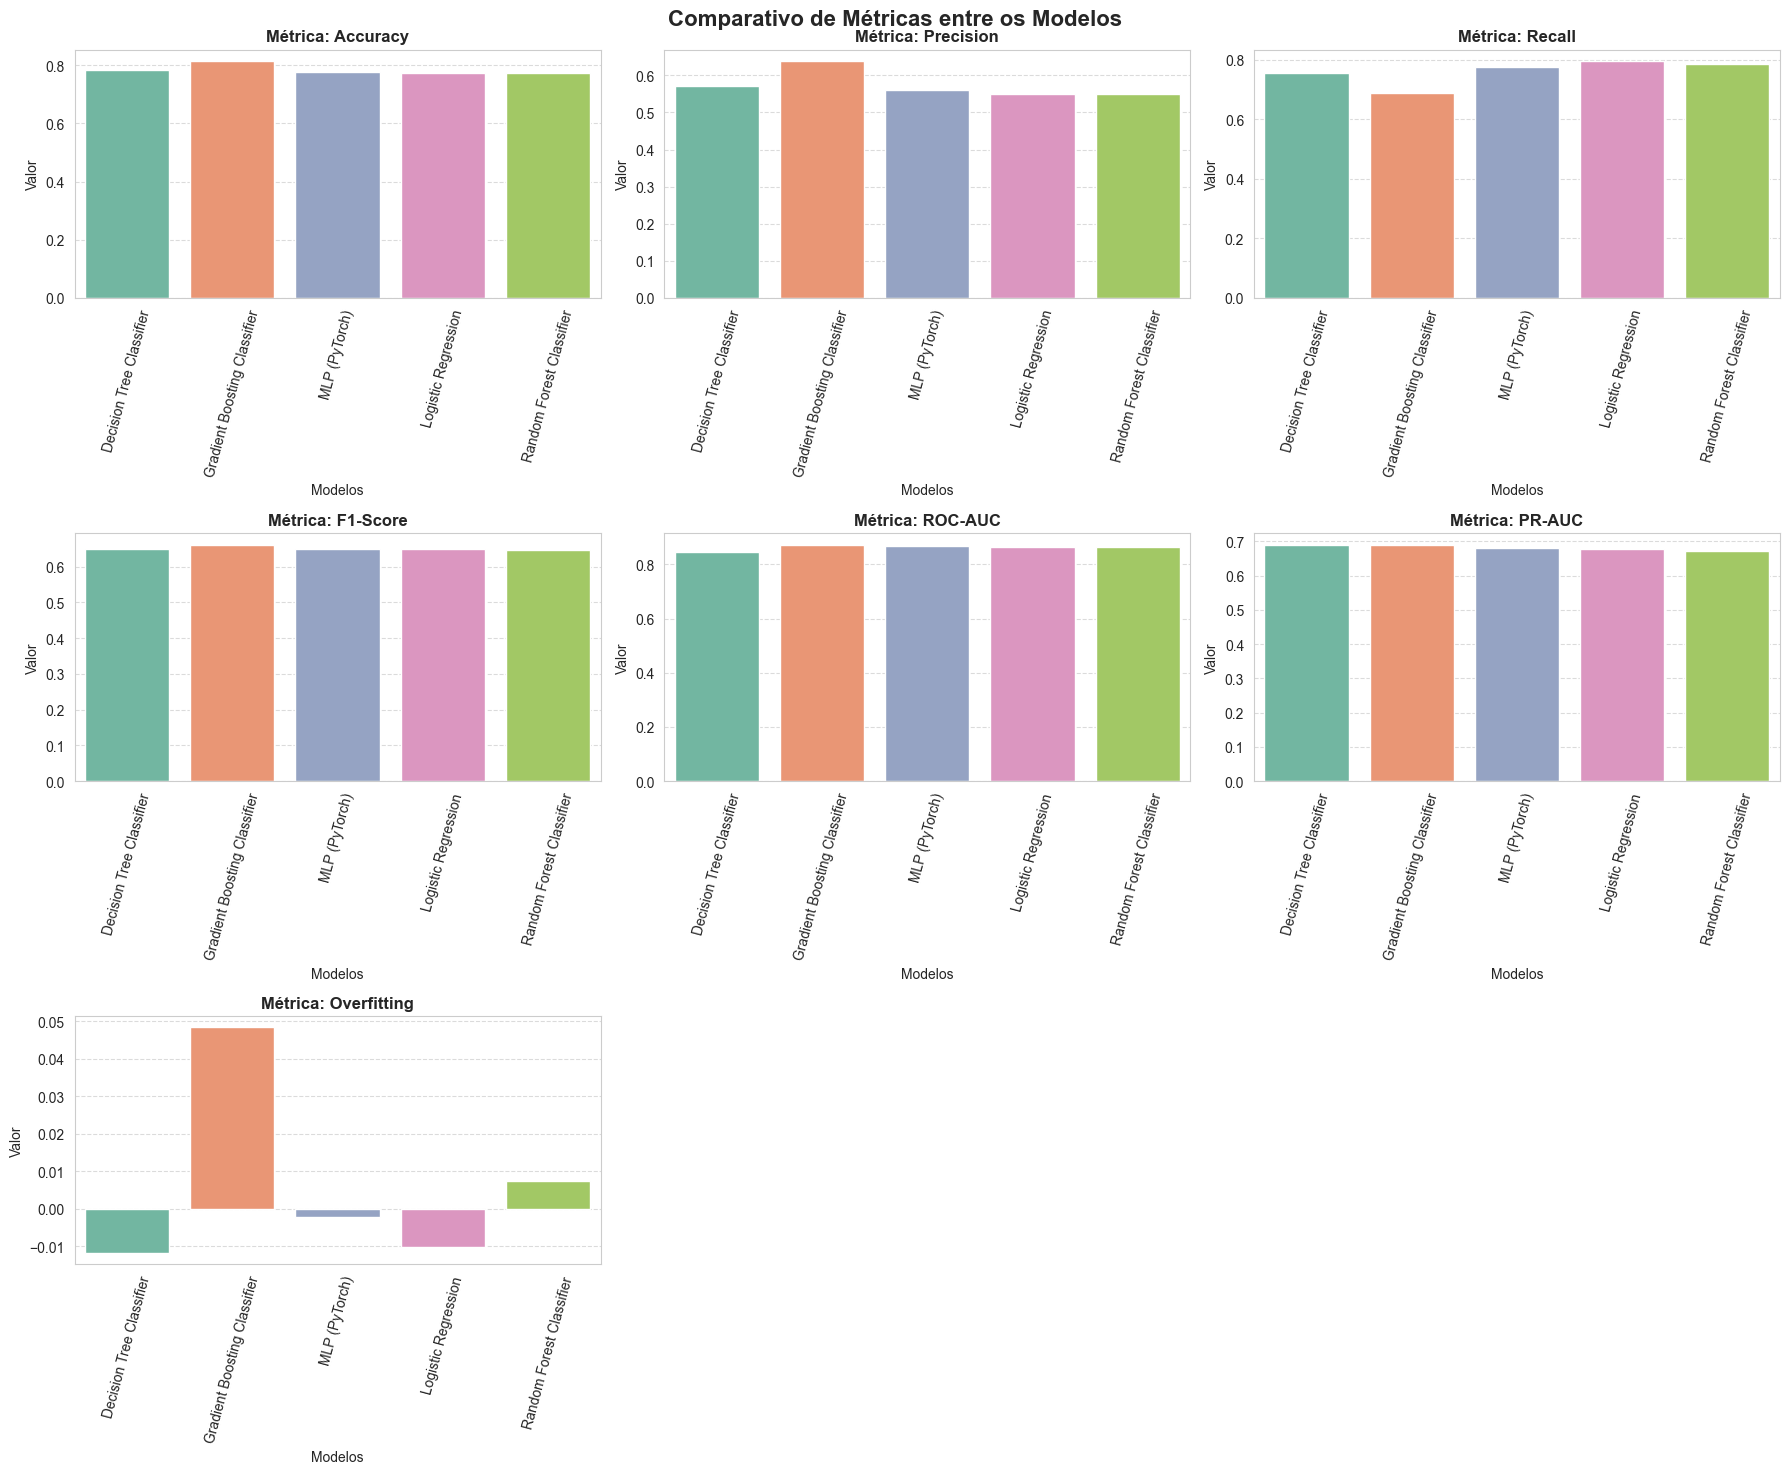

2026-06-11 22:41:05,783 - tc_etapa_02 - INFO - Programa finalizado


In [123]:
if __name__ == "__main__":
    main()